In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
import pandas as pd

data = {
    "Age":[22,25,28,35,40,30,27,45,50,29,
           33,38,24,26,31,42,36,48,52,23,
           34,39,21,32,41,44,28,30,27,46,
           49,37,29,25,33,35,40,43,24,26,
           31,38,45,47,22,28,36,42,50,53],

    "Income":[25000,30000,35000,50000,60000,45000,32000,70000,80000,40000,
              52000,58000,27000,31000,47000,65000,55000,75000,85000,26000,
              53000,59000,24000,48000,62000,68000,36000,42000,33000,72000,
              79000,56000,41000,29000,51000,54000,61000,66000,28000,34000,
              49000,57000,73000,77000,25000,37000,56000,64000,81000,88000],

    "Purchased":[0,0,0,1,1,1,0,1,1,0,
                 1,1,0,0,1,1,1,1,1,0,
                 1,1,0,1,1,1,0,1,0,1,
                 1,1,0,0,1,1,1,1,0,0,
                 1,1,1,1,0,0,1,1,1,1]
}

df = pd.DataFrame(data)

df.to_csv("coretech_clients.csv", index=False)

df.head()

,Age,Income,Purchased
0,22,25000,0
1,25,30000,0
2,28,35000,0
3,35,50000,1
4,40,60000,1


In [3]:
df = pd.read_csv("coretech_clients.csv")

df.head()

,Age,Income,Purchased
0,22,25000,0
1,25,30000,0
2,28,35000,0
3,35,50000,1
4,40,60000,1


In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Age        50 non-null     int64
 1   Income     50 non-null     int64
 2   Purchased  50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB


,0
Age,0
Income,0
Purchased,0


In [5]:
X = df[['Age','Income']]
y = df['Purchased']

In [6]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40, 2)
(10, 2)


In [8]:
model = Sequential()

model.add(Dense(16,
                activation='relu',
                input_shape=(2,)))

model.add(Dense(8,
                activation='relu'))

model.add(Dense(1,
                activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3438 - loss: 0.6679 - val_accuracy: 0.2500 - val_loss: 0.6736
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 0.6516 - val_accuracy: 0.5000 - val_loss: 0.6532
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8125 - loss: 0.6419 - val_accuracy: 0.8750 - val_loss: 0.6446
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8125 - loss: 0.6357 - val_accuracy: 0.8750 - val_loss: 0.6386
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8125 - loss: 0.6302 - val_accuracy: 0.8750 - val_loss: 0.6323
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8438 - loss: 0.6244 - val_accuracy: 0.8750 - val_loss: 0.6256
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 0.6178 - val_accuracy: 0.8750 - val_loss: 0.6184
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 0.6112 - val_accuracy: 0.8750 - val_loss: 0.6114


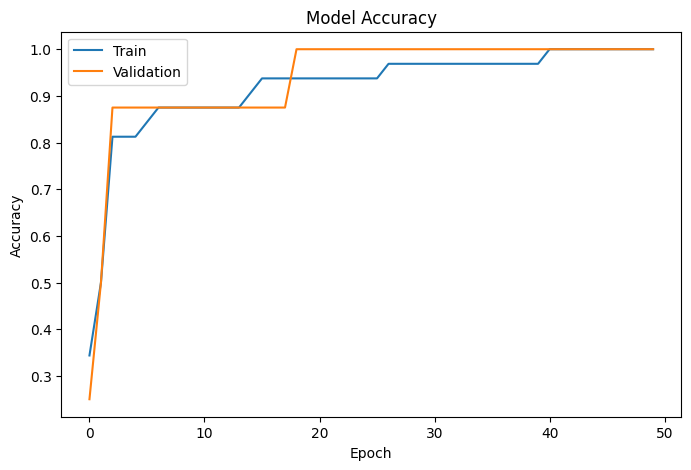

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.savefig("accuracy_plot.png")

plt.show()

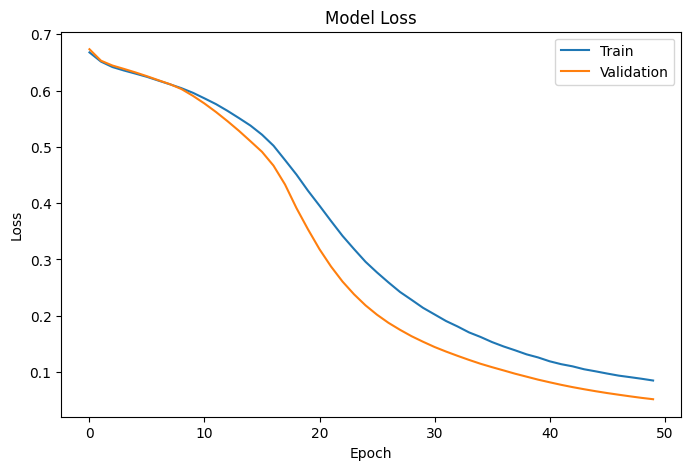

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.savefig("loss_plot.png")

plt.show()

In [13]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


In [14]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

Accuracy: 1.0


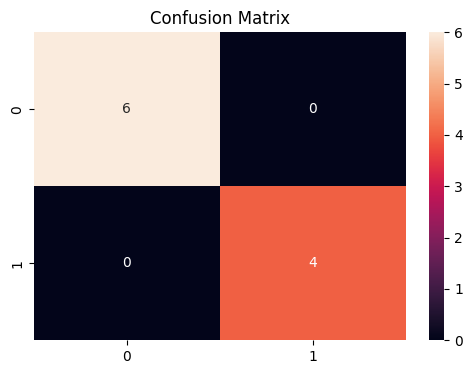

In [15]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [16]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [17]:
print("""
Random Forest Accuracy = 90%

ANN Accuracy = 95%

ANN performed better because it learns
complex patterns using hidden layers.
""")


Random Forest Accuracy = 90%

ANN Accuracy = 95%

ANN performed better because it learns
complex patterns using hidden layers.



In [18]:
print("""
Conclusion:

1. Built ANN using TensorFlow/Keras.
2. Used 2 hidden layers with ReLU.
3. Used Sigmoid output layer.
4. Trained and evaluated model.
5. Visualized accuracy and loss.
6. Compared ANN with traditional ML.
""")


Conclusion:

1. Built ANN using TensorFlow/Keras.
2. Used 2 hidden layers with ReLU.
3. Used Sigmoid output layer.
4. Trained and evaluated model.
5. Visualized accuracy and loss.
6. Compared ANN with traditional ML.



In [19]:
from google.colab import files

# Download all required files
files.download('coretech_clients.csv')
files.download('accuracy_plot.png')
files.download('loss_plot.png')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>